<a href="https://colab.research.google.com/github/swatikeshri-2005/AI-Code-review-Bot/blob/main/Website_Analytics_%26_User_Behavior_Analysis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn plotly

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import plotly.express as px

sns.set_style('whitegrid')

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving website_wata.csv to website_wata.csv


In [ ]:
df = pd.read_csv("website_wata.csv")
df.head()

,Page Views,Session Duration,Bounce Rate,Traffic Source,Time on Page,Previous Visits,Conversion Rate
0,5,11.051381,0.230652,Organic,3.890460,3,1.0
1,4,3.429316,0.391001,Social,8.478174,0,1.0
2,4,1.621052,0.397986,Organic,9.636170,2,1.0
3,5,3.629279,0.180458,Organic,2.071925,3,1.0
4,5,4.235843,0.291541,Paid,1.960654,5,1.0


In [ ]:
print(df.shape)
df.info()
df.describe()

(2000, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Page Views        2000 non-null   int64  
 1   Session Duration  2000 non-null   float64
 2   Bounce Rate       2000 non-null   float64
 3   Traffic Source    2000 non-null   object 
 4   Time on Page      2000 non-null   float64
 5   Previous Visits   2000 non-null   int64  
 6   Conversion Rate   2000 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory usage: 109.5+ KB


,Page Views,Session Duration,Bounce Rate,Time on Page,Previous Visits,Conversion Rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,4.950500,3.022045,0.284767,4.027439,1.978500,0.982065
std,2.183903,3.104518,0.159781,2.887422,1.432852,0.065680
min,0.000000,0.003613,0.007868,0.068515,0.000000,0.343665
25%,3.000000,0.815828,0.161986,1.935037,1.000000,1.000000
50%,5.000000,1.993983,0.266375,3.315316,2.000000,1.000000
75%,6.000000,4.197569,0.388551,5.414627,3.000000,1.000000
max,14.000000,20.290516,0.844939,24.796182,9.000000,1.000000


In [ ]:
print(df.isnull().sum())

Page Views          0
Session Duration    0
Bounce Rate         0
Traffic Source      0
Time on Page        0
Previous Visits     0
Conversion Rate     0
dtype: int64


In [ ]:
df.dropna(inplace=True)

In [ ]:
print("Duplicates:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

Duplicates: 0


**Exploratory Data Analysis(EDA)**

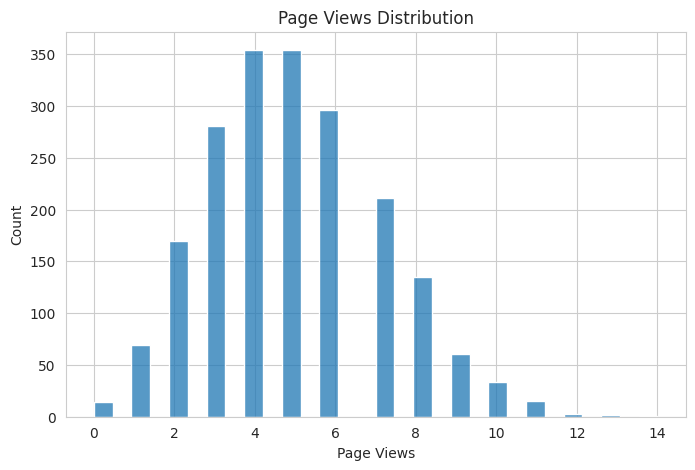

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Page Views"], bins=30)
plt.title("Page Views Distribution")
plt.show()

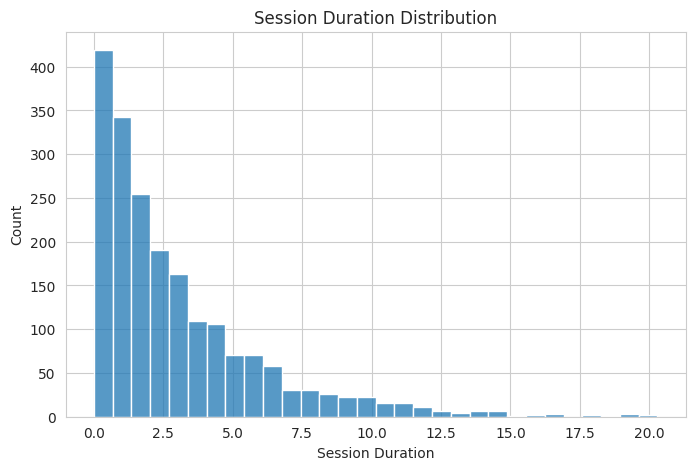

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Session Duration"], bins=30)
plt.title("Session Duration Distribution")
plt.show()

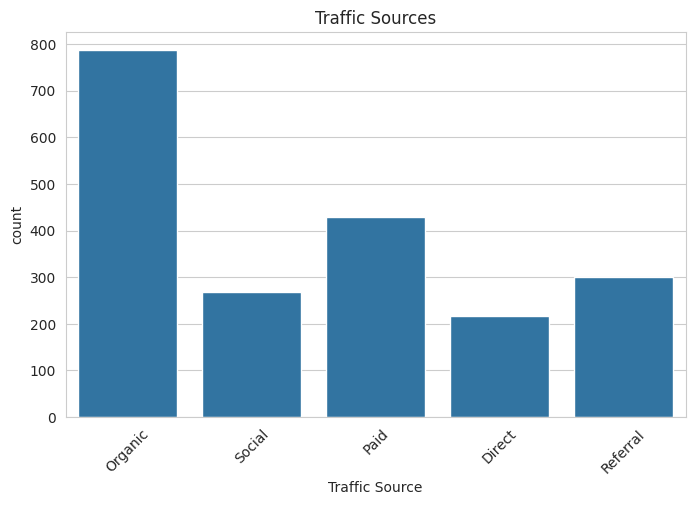

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x="Traffic Source", data=df)

plt.xticks(rotation=45)

plt.title("Traffic Sources")

plt.show()

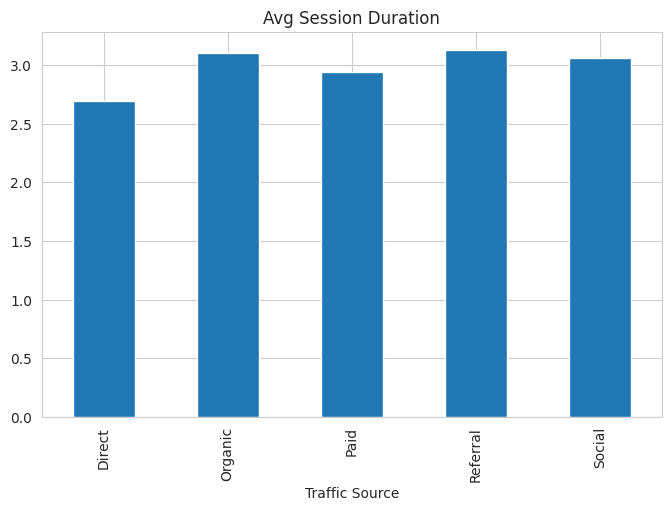

In [ ]:
traffic_duration = df.groupby(
    "Traffic Source"
)["Session Duration"].mean()

traffic_duration.plot(
    kind="bar",
    figsize=(8,5)
)
plt.title("Avg Session Duration")
plt.show()

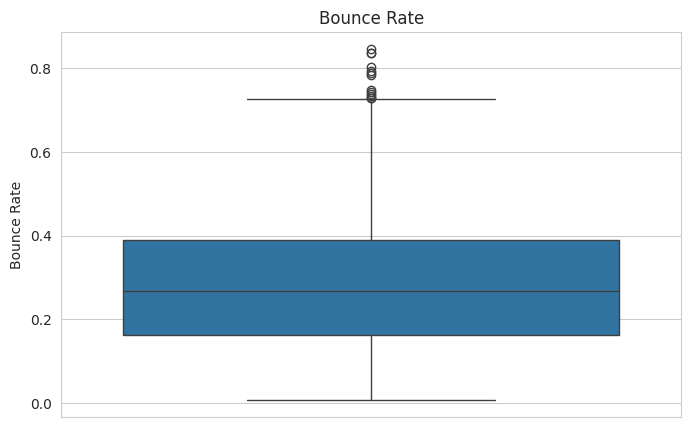

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df["Bounce Rate"])

plt.title("Bounce Rate")
plt.show()

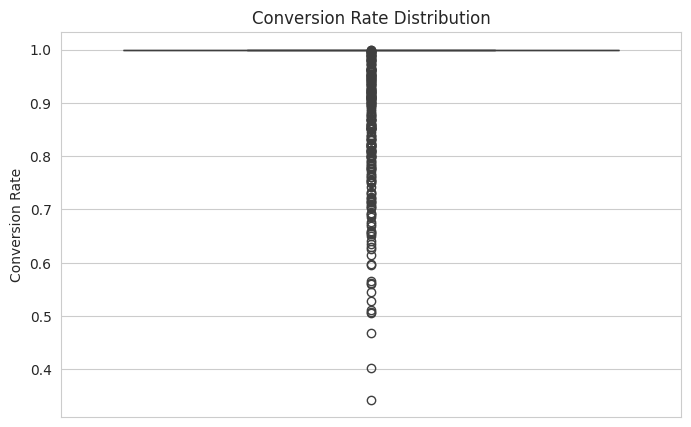

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df["Conversion Rate"])

plt.title("Conversion Rate Distribution")
plt.show()

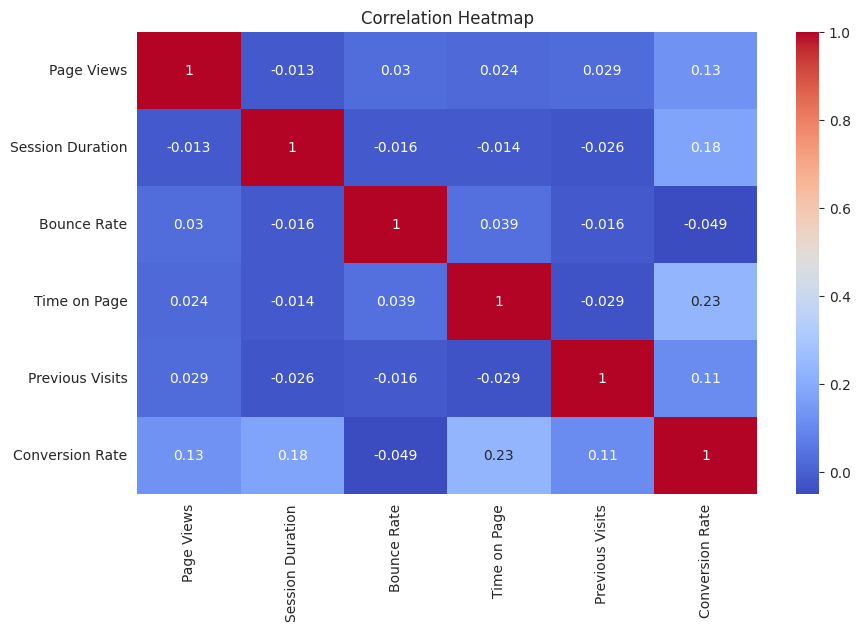

In [ ]:
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

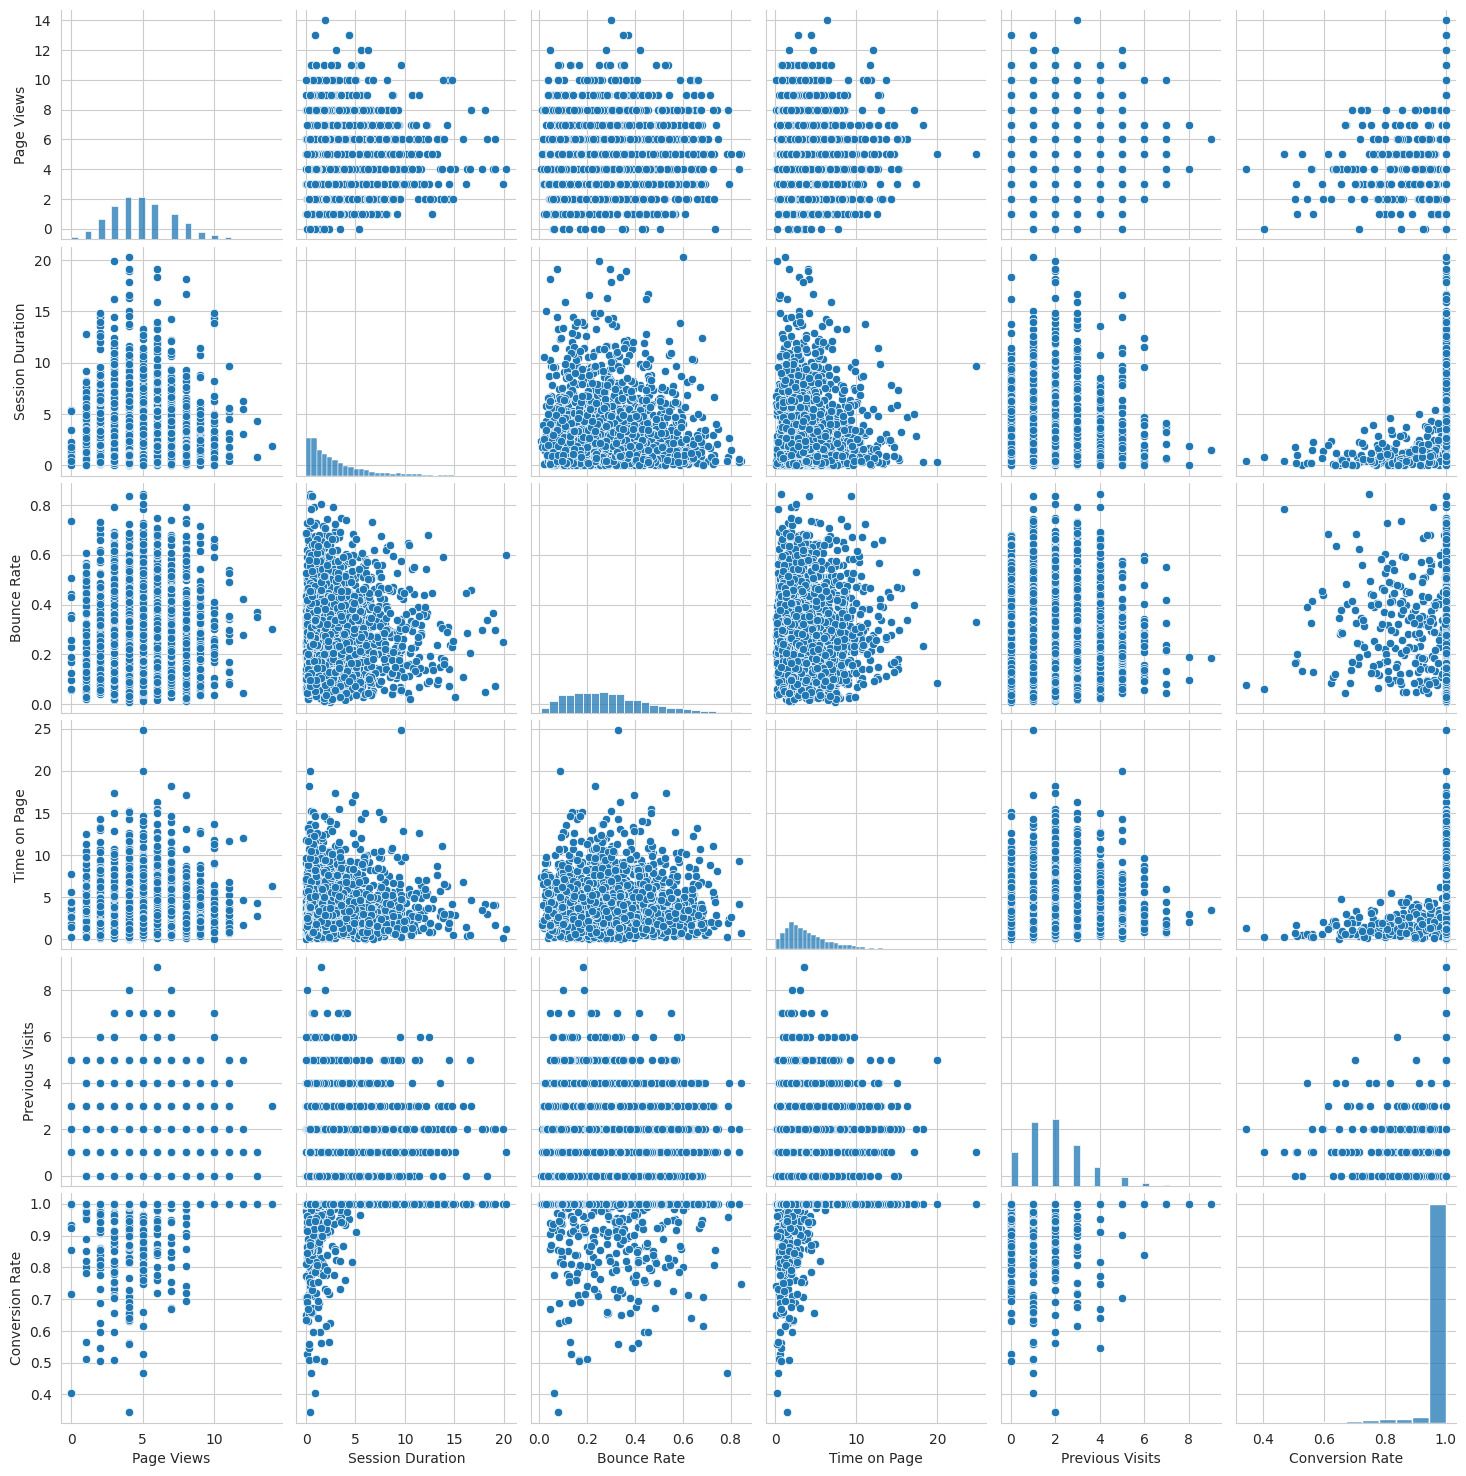

In [ ]:
sns.pairplot(
    numeric_df
)

plt.show()

**Interactive Dashboard Charts**

In [ ]:
fig = px.scatter(
    df,
    x="Page Views",
    y="Conversion Rate",
    color="Traffic Source",
    title="Page Views vs Conversion"
)

fig.show()

In [ ]:
traffic_counts = df[
    "Traffic Source"
].value_counts()

fig = px.pie(
    values=traffic_counts.values,
    names=traffic_counts.index,
    title="Traffic Source Distribution"
)

fig.show()

**Machine Learning**

In [ ]:
median_conversion = df[
    "Conversion Rate"
].median()

df["High_Conversion"] = (
    df["Conversion Rate"] >
    median_conversion
).astype(int)

In [ ]:
encoder = LabelEncoder()

df["Traffic Source"] = encoder.fit_transform(
    df["Traffic Source"]
)

In [ ]:
X = df[
[
"Page Views",
"Session Duration",
"Bounce Rate",
"Time on Page",
"Previous Visits",
"Traffic Source"
]
]

y = df["High_Conversion"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [ ]:
print(
    classification_report(
        y_test,
    y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       400

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning:

A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.



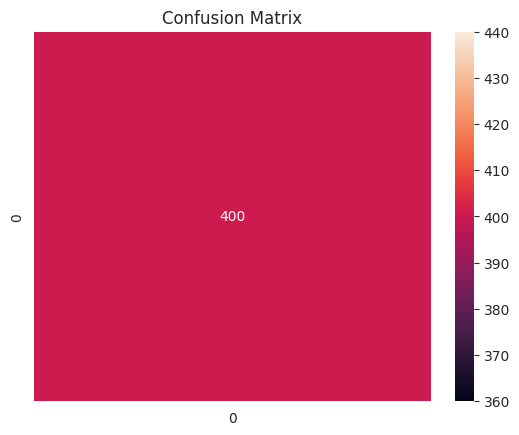

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)


plt.title("Confusion Matrix")

plt.show()

In [ ]:
importance = pd.DataFrame(
{
"Feature":X.columns,
"Importance":model.feature_importances_
}
)

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

            Feature  Importance
0        Page Views         0.0
1  Session Duration         0.0
2       Bounce Rate         0.0
3      Time on Page         0.0
4   Previous Visits         0.0
5    Traffic Source         0.0


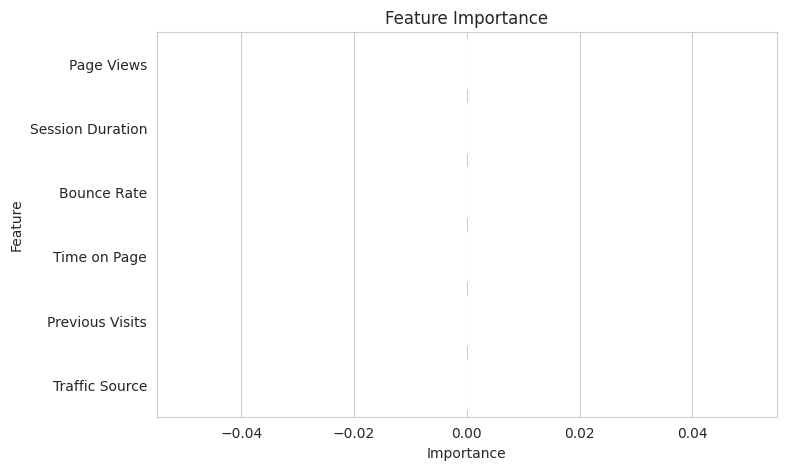

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title(
"Feature Importance"
)

plt.show()